# 🏦 Clasificación de Gastos/Ingresos mediante PLN

Este notebook entrena y compara diferentes modelos de **Procesamiento de Lenguaje Natural** para clasificar transacciones bancarias en **"Expenses"** o **"Income"** a partir de su descripción textual.

## Modelos entrenados:
1. **Naive Bayes (MultinomialNB)** – baseline clásico para clasificación de texto
2. **Logistic Regression** con TF-IDF – modelo lineal robusto
3. **SVM (Support Vector Machine)** con TF-IDF – excelente en espacios de alta dimensión
4. **Random Forest** con TF-IDF – modelo ensemble no lineal
5. **Gradient Boosting (HistGradientBoosting)** con TF-IDF – boosting eficiente

---

## 1. Importaciones y Configuración

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Carga y preparación de datos

In [22]:
# Ruta al dataset
DATA_PATH = os.path.join("..", "data", "raw", "db_orig.csv")

df_raw = pd.read_csv(DATA_PATH)
print(f"📊 Dataset cargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"   Columnas: {list(df_raw.columns)}")
df_raw.head()

📊 Dataset cargado: 885 filas x 5 columnas
   Columnas: ['Description', 'Date', 'Amount', 'Area', 'Type']


,Description,Date,Amount,Area,Type
0,Entretenimiento,28/02/2026,"10,00€",Leisure,Expenses
1,Nómina mensual,27/02/2026,"629,58€",Salary,Income
2,Gasto vacaciones,25/02/2026,"51,00€","Leisure, Vacations",Expenses
3,Pequeño ocio,22/02/2026,"2,80€",Leisure,Expenses
4,Compra alimentación,21/02/2026,"24,80€",Food,Expenses


In [23]:
# Nos quedamos SOLO con Description y Type
df = df_raw[["Description", "Type"]].copy()

# Eliminar filas con valores nulos
nulos_antes = df.isnull().sum().sum()
df.dropna(inplace=True)
print(f"🧹 Valores nulos eliminados: {nulos_antes}")
print(f"📋 Dataset final: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

🧹 Valores nulos eliminados: 0
📋 Dataset final: 885 filas x 2 columnas


,Description,Type
0,Entretenimiento,Expenses
1,Nómina mensual,Income
2,Gasto vacaciones,Expenses
3,Pequeño ocio,Expenses
4,Compra alimentación,Expenses


## 3. Análisis exploratorio (EDA)

📈 Distribución de clases:
Type
Expenses    713
Income      172
Name: count, dtype: int64

➡️  Ratio Expenses/Income: 4.15


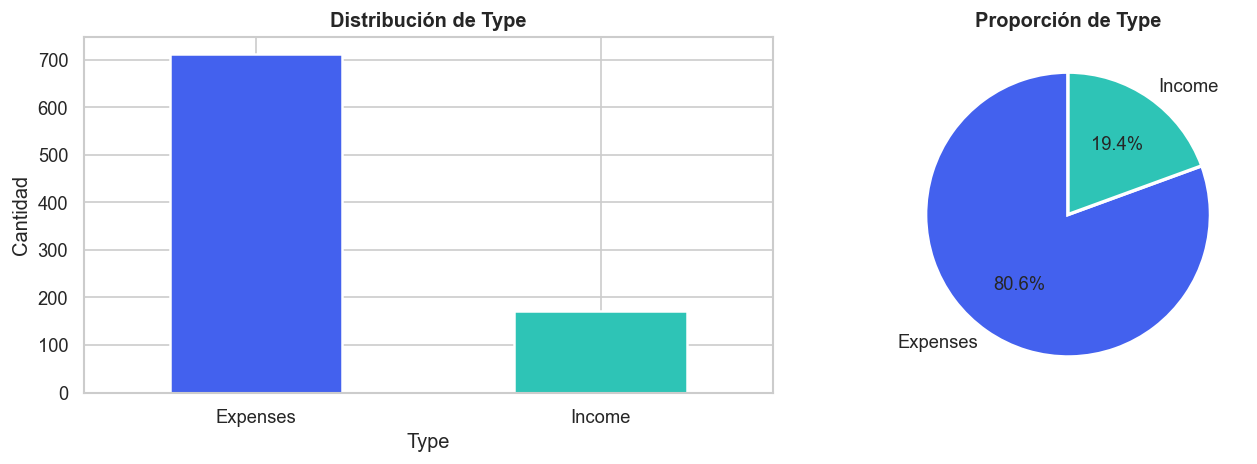

In [24]:
# Distribución de clases
print("📈 Distribución de clases:")
print(df["Type"].value_counts())
print(f"\n➡️  Ratio Expenses/Income: {df[df['Type']=='Expenses'].shape[0] / df[df['Type']=='Income'].shape[0]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
colors = ["#4361ee", "#2ec4b6"]
df["Type"].value_counts().plot(
    kind="bar", ax=axes[0], color=colors, edgecolor="white", linewidth=1.5
)
axes[0].set_title("Distribución de Type", fontweight="bold")
axes[0].set_ylabel("Cantidad")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Gráfico circular
df["Type"].value_counts().plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_ylabel("")
axes[1].set_title("Proporción de Type", fontweight="bold")

plt.tight_layout()
plt.show()

📏 Estadísticas de longitud de descripción:
         desc_length                                          num_words       \
               count  mean  std   min   25%   50%   75%   max     count mean   
Type                                                                           
Expenses       713.0  15.7  2.8  12.0  12.0  15.0  18.0  24.0     713.0  1.8   
Income         172.0  14.5  0.6  14.0  14.0  15.0  15.0  16.0     172.0  2.0   

                                        
          std  min  25%  50%  75%  max  
Type                                    
Expenses  0.5  1.0  2.0  2.0  2.0  3.0  
Income    0.0  2.0  2.0  2.0  2.0  2.0  


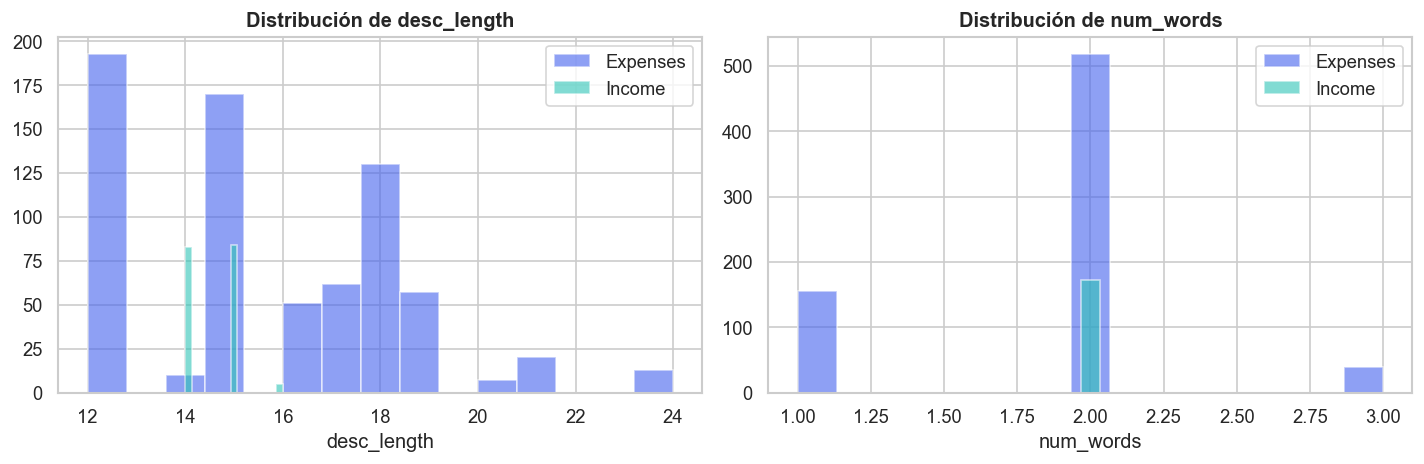

In [25]:
# Descripción de los textos
df["desc_length"] = df["Description"].str.len()
df["num_words"] = df["Description"].str.split().str.len()

print("📏 Estadísticas de longitud de descripción:")
print(df.groupby("Type")[["desc_length", "num_words"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(["desc_length", "num_words"]):
    for tipo, color in zip(["Expenses", "Income"], colors):
        data = df[df["Type"] == tipo][col]
        axes[i].hist(data, bins=15, alpha=0.6, label=tipo, color=color, edgecolor="white")
    axes[i].set_title(f"Distribución de {col}", fontweight="bold")
    axes[i].legend()
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# Eliminar columnas auxiliares
df.drop(columns=["desc_length", "num_words"], inplace=True)

In [26]:
# Descripciones únicas por tipo
print("🔤 Descripciones más frecuentes por tipo:\n")
for tipo in df["Type"].unique():
    subset = df[df["Type"] == tipo]
    print(f"--- {tipo} (top 10) ---")
    print(subset["Description"].value_counts().head(10))
    print()

🔤 Descripciones más frecuentes por tipo:

--- Expenses (top 10) ---
Description
Gasto alimentación          119
Factura pequeña             105
Pequeño ocio                101
Microfactura                 92
Entretenimiento              63
Pequeña inversión            59
Compra alimentación          47
Factura servicio             38
Gasto food, vacations        20
Gasto invoice, vacations     13
Name: count, dtype: int64

--- Income (top 10) ---
Description
Pequeño ingreso     84
Nómina mensual      83
Ingreso depósito     5
Name: count, dtype: int64



## 4. División Train / Test (80-20)

In [27]:
X = df["Description"]
y = df["Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"🔀 División estratificada 80/20:")
print(f"   Train: {X_train.shape[0]} muestras")
print(f"   Test:  {X_test.shape[0]} muestras")
print(f"\n📊 Distribución en Train:\n{y_train.value_counts()}")
print(f"\n📊 Distribución en Test:\n{y_test.value_counts()}")

🔀 División estratificada 80/20:
   Train: 708 muestras
   Test:  177 muestras

📊 Distribución en Train:
Type
Expenses    570
Income      138
Name: count, dtype: int64

📊 Distribución en Test:
Type
Expenses    143
Income       34
Name: count, dtype: int64


## 5. Definición de Modelos (Pipelines)

Cada pipeline incluye:
- **Vectorización TF-IDF** (o CountVectorizer para Naive Bayes) con n-gramas (1,2)
- **Modelo de clasificación**

In [28]:
# Transformer auxiliar para convertir sparse -> dense (necesario para HistGradientBoosting)
to_dense = FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)

# Definimos los pipelines de PLN
pipelines = {
    "Naive Bayes (BoW)": Pipeline([
        ("vectorizer", CountVectorizer(
            ngram_range=(1, 2),
            max_features=5000,
            lowercase=True,
            strip_accents="unicode",
        )),
        ("clf", MultinomialNB(alpha=0.1)),
    ]),
    "Logistic Regression (TF-IDF)": Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000,
            lowercase=True,
            strip_accents="unicode",
            sublinear_tf=True,
        )),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=SEED,
            C=1.0,
            solver="lbfgs",
        )),
    ]),
    "SVM Lineal (TF-IDF)": Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000,
            lowercase=True,
            strip_accents="unicode",
            sublinear_tf=True,
        )),
        ("clf", LinearSVC(
            max_iter=2000,
            random_state=SEED,
            C=1.0,
        )),
    ]),
    "Random Forest (TF-IDF)": Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000,
            lowercase=True,
            strip_accents="unicode",
            sublinear_tf=True,
        )),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=SEED,
            n_jobs=-1,
        )),
    ]),
    "HistGradientBoosting (TF-IDF)": Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=5000,
            lowercase=True,
            strip_accents="unicode",
            sublinear_tf=True,
        )),
        ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
        ("clf", HistGradientBoostingClassifier(
            max_iter=200,
            max_depth=6,
            random_state=SEED,
        )),
    ]),
}

print(f"🤖 {len(pipelines)} modelos definidos:")
for name in pipelines:
    print(f"   • {name}")

🤖 5 modelos definidos:
   • Naive Bayes (BoW)
   • Logistic Regression (TF-IDF)
   • SVM Lineal (TF-IDF)
   • Random Forest (TF-IDF)
   • HistGradientBoosting (TF-IDF)


## 6. Entrenamiento y Validación Cruzada

In [29]:
# Entrenamos cada modelo y evaluamos con validación cruzada (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []

for name, pipeline in pipelines.items():
    print(f"\n🔄 Entrenando: {name}...")
    
    # Validación cruzada sobre el conjunto de train
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_weighted")
    
    # Entrenar sobre todo el train set
    pipeline.fit(X_train, y_train)
    
    # Predecir sobre test
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    
    results.append({
        "Modelo": name,
        "CV F1 (media)": cv_scores.mean(),
        "CV F1 (std)": cv_scores.std(),
        "Test Accuracy": acc,
        "Test F1": f1,
        "Test Precision": prec,
        "Test Recall": rec,
    })
    
    print(f"   CV F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"   Test → Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")

print("\n✅ Todos los modelos entrenados")


🔄 Entrenando: Naive Bayes (BoW)...
   CV F1: 1.0000 (±0.0000)
   Test → Accuracy: 1.0000 | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000

🔄 Entrenando: Logistic Regression (TF-IDF)...
   CV F1: 0.9971 (±0.0057)
   Test → Accuracy: 1.0000 | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000

🔄 Entrenando: SVM Lineal (TF-IDF)...
   CV F1: 1.0000 (±0.0000)
   Test → Accuracy: 1.0000 | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000

🔄 Entrenando: Random Forest (TF-IDF)...
   CV F1: 1.0000 (±0.0000)
   Test → Accuracy: 1.0000 | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000

🔄 Entrenando: HistGradientBoosting (TF-IDF)...
   CV F1: 1.0000 (±0.0000)
   Test → Accuracy: 1.0000 | F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000

✅ Todos los modelos entrenados


## 7. Comparativa de Modelos

In [30]:
# Tabla resumen
df_results = pd.DataFrame(results).sort_values("Test F1", ascending=False)
df_results.index = range(1, len(df_results) + 1)

print("📊 TABLA COMPARATIVA DE MODELOS:\n")
display(df_results.style.format({
    "CV F1 (media)": "{:.4f}",
    "CV F1 (std)": "{:.4f}",
    "Test Accuracy": "{:.4f}",
    "Test F1": "{:.4f}",
    "Test Precision": "{:.4f}",
    "Test Recall": "{:.4f}",
}).highlight_max(subset=["Test F1", "Test Accuracy"], color="#a8e6cf")
 .highlight_min(subset=["CV F1 (std)"], color="#a8e6cf"))

📊 TABLA COMPARATIVA DE MODELOS:



,Modelo,CV F1 (media),CV F1 (std),Test Accuracy,Test F1,Test Precision,Test Recall
1,Naive Bayes (BoW),1.0000,0.0000,1.0000,1.0000,1.0000,1.0000
2,Logistic Regression (TF-IDF),0.9971,0.0057,1.0000,1.0000,1.0000,1.0000
3,SVM Lineal (TF-IDF),1.0000,0.0000,1.0000,1.0000,1.0000,1.0000
4,Random Forest (TF-IDF),1.0000,0.0000,1.0000,1.0000,1.0000,1.0000
5,HistGradientBoosting (TF-IDF),1.0000,0.0000,1.0000,1.0000,1.0000,1.0000


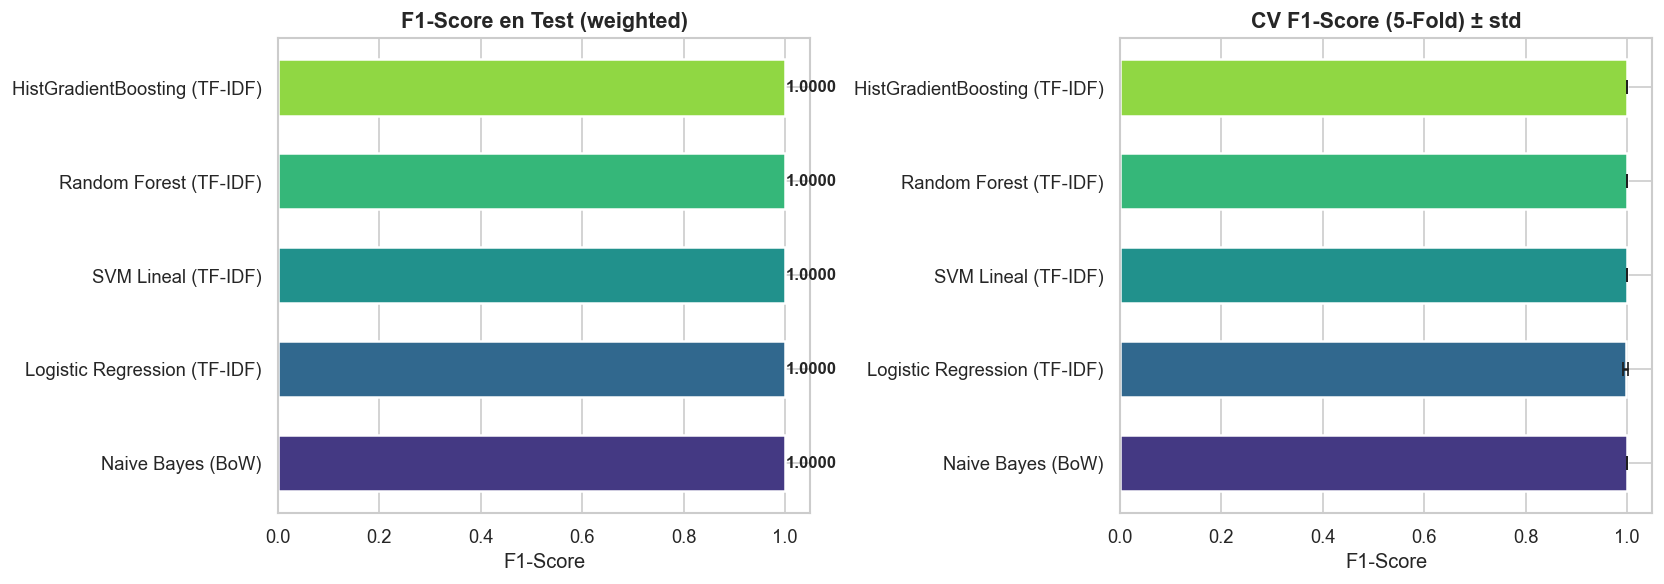

💾 Gráfico guardado: resultados_comparativa.png


In [31]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- F1 Score en Test ---
df_sorted = df_results.sort_values("Test F1", ascending=True)
palette = sns.color_palette("viridis", n_colors=len(df_sorted))

bars = axes[0].barh(
    df_sorted["Modelo"],
    df_sorted["Test F1"],
    color=palette,
    edgecolor="white",
    linewidth=1.5,
    height=0.6,
)
for bar, val in zip(bars, df_sorted["Test F1"]):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.4f}",
                 va="center", fontsize=10, fontweight="bold")

axes[0].set_xlim(0, 1.05)
axes[0].set_title("F1-Score en Test (weighted)", fontweight="bold", fontsize=13)
axes[0].set_xlabel("F1-Score")

# --- CV F1 con barras de error ---
axes[1].barh(
    df_sorted["Modelo"],
    df_sorted["CV F1 (media)"],
    xerr=df_sorted["CV F1 (std)"],
    color=palette,
    edgecolor="white",
    linewidth=1.5,
    height=0.6,
    capsize=4,
)
axes[1].set_xlim(0, 1.05)
axes[1].set_title("CV F1-Score (5-Fold) ± std", fontweight="bold", fontsize=13)
axes[1].set_xlabel("F1-Score")

plt.tight_layout()
plt.savefig("resultados_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: resultados_comparativa.png")

## 8. Matrices de Confusión

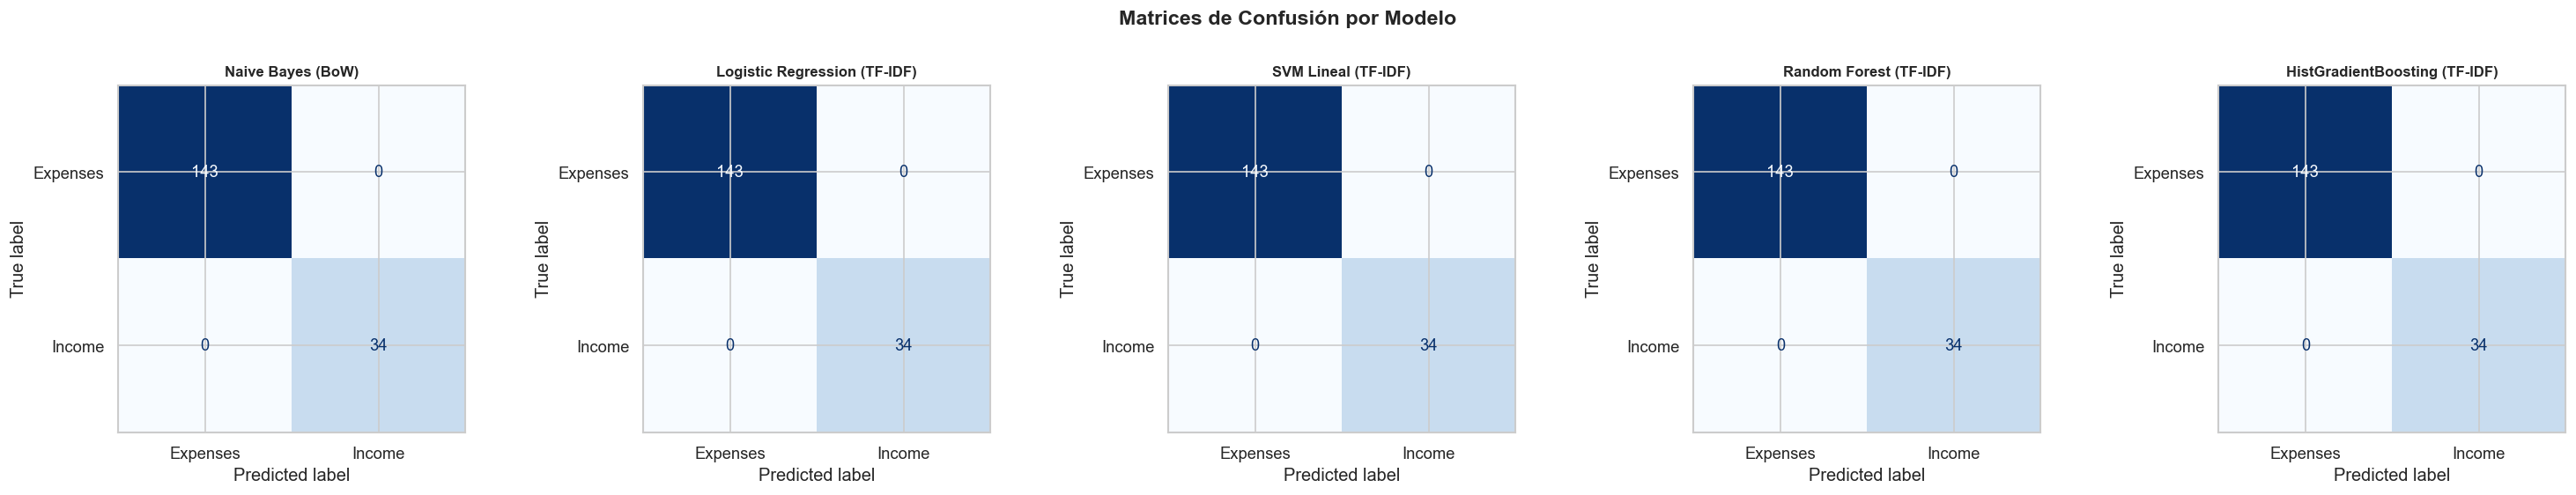

💾 Gráfico guardado: matrices_confusion.png


In [32]:
n_models = len(pipelines)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))

labels = sorted(y.unique())
for ax, (name, pipeline) in zip(axes, pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name, fontweight="bold", fontsize=10)

plt.suptitle("Matrices de Confusión por Modelo", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: matrices_confusion.png")

## 9. Classification Report del Mejor Modelo

In [33]:
# Seleccionamos el mejor modelo según F1 en test
best_name = df_results.iloc[0]["Modelo"]
best_pipeline = pipelines[best_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"🏆 MEJOR MODELO: {best_name}\n")
print("═" * 60)
print(classification_report(y_test, y_pred_best, digits=4))
print("═" * 60)

🏆 MEJOR MODELO: Naive Bayes (BoW)

════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Expenses     1.0000    1.0000    1.0000       143
      Income     1.0000    1.0000    1.0000        34

    accuracy                         1.0000       177
   macro avg     1.0000    1.0000    1.0000       177
weighted avg     1.0000    1.0000    1.0000       177

════════════════════════════════════════════════════════════


## 10. Análisis de Errores

In [34]:
# Identificar las predicciones erróneas del mejor modelo
df_test = pd.DataFrame({
    "Description": X_test.values,
    "Real": y_test.values,
    "Predicción": y_pred_best,
})
df_errors = df_test[df_test["Real"] != df_test["Predicción"]]

print(f"❌ Errores del mejor modelo ({best_name}):")
print(f"   Total errores: {len(df_errors)} de {len(df_test)} ({100*len(df_errors)/len(df_test):.1f}%)\n")

if len(df_errors) > 0:
    display(df_errors.reset_index(drop=True))
else:
    print("   ¡Sin errores! El modelo clasificó todas las muestras correctamente.")

❌ Errores del mejor modelo (Naive Bayes (BoW)):
   Total errores: 0 de 177 (0.0%)

   ¡Sin errores! El modelo clasificó todas las muestras correctamente.


## 11. Importancia de Palabras (Modelos Lineales)

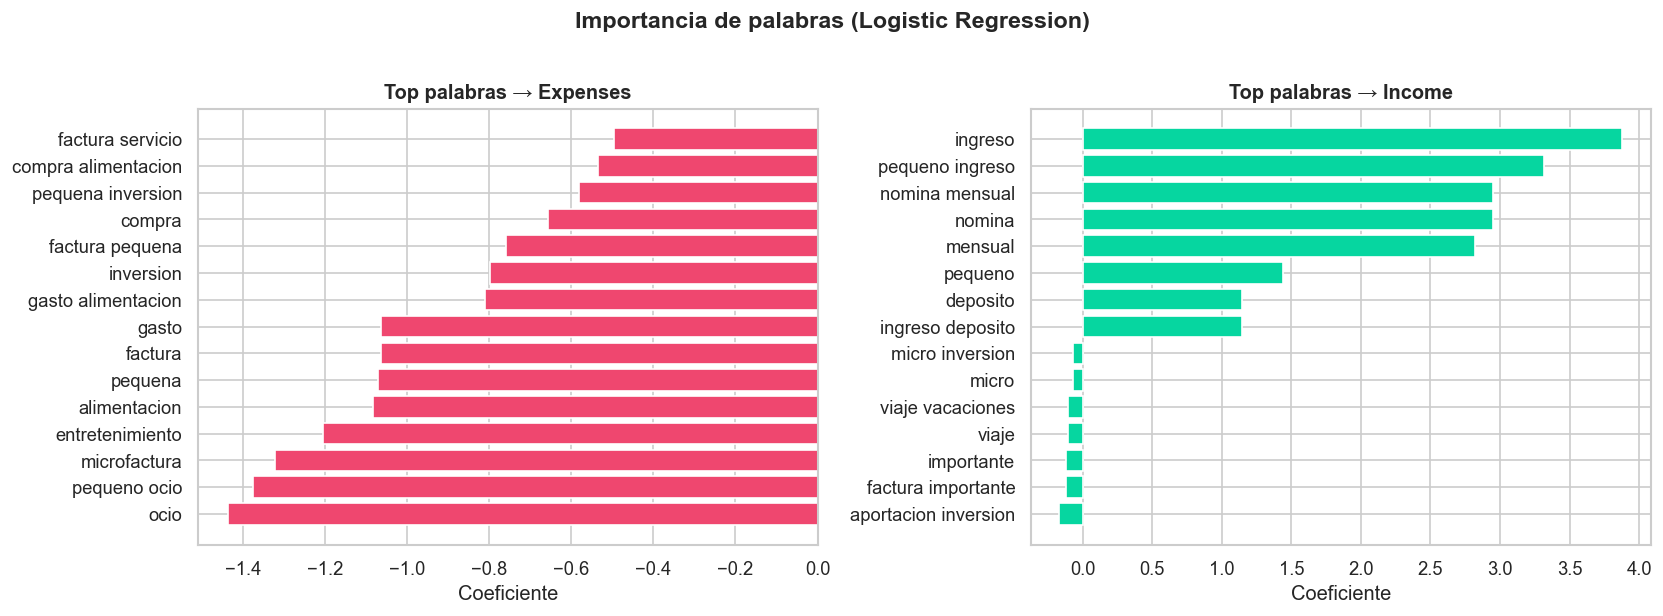

💾 Gráfico guardado: importancia_palabras.png


In [35]:
# Analizamos las palabras más importantes para Logistic Regression
lr_pipe = pipelines["Logistic Regression (TF-IDF)"]
vectorizer = lr_pipe.named_steps["vectorizer"]
clf = lr_pipe.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

# Top palabras para cada clase
top_n = 15
top_expenses_idx = np.argsort(coefs)[:top_n]
top_income_idx = np.argsort(coefs)[-top_n:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palabras más indicativas de Expenses (coeficientes negativos si Expenses < Income)
words_exp = feature_names[top_expenses_idx]
vals_exp = coefs[top_expenses_idx]
axes[0].barh(words_exp, vals_exp, color="#ef476f", edgecolor="white")
axes[0].set_title("Top palabras → Expenses", fontweight="bold")
axes[0].set_xlabel("Coeficiente")

# Palabras más indicativas de Income (coeficientes positivos)
words_inc = feature_names[top_income_idx]
vals_inc = coefs[top_income_idx]
axes[1].barh(words_inc, vals_inc, color="#06d6a0", edgecolor="white")
axes[1].set_title("Top palabras → Income", fontweight="bold")
axes[1].set_xlabel("Coeficiente")

plt.suptitle("Importancia de palabras (Logistic Regression)", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("importancia_palabras.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: importancia_palabras.png")

## 12. Prueba con Nuevas Descripciones

In [36]:
# Probemos el mejor modelo con descripciones inventadas
nuevas_descripciones = [
    "Nómina mensual",
    "Compra supermercado",
    "Factura servicio",
    "Ingreso depósito",
    "Pequeño ocio",
    "Pequeño ingreso",
    "Entretenimiento",
    "Inversión mensual",
    "Gasto vacaciones",
    "Pago de luz",
    "Cobro freelance",
    "Compra ropa online",
]

predicciones = best_pipeline.predict(nuevas_descripciones)

df_nuevas = pd.DataFrame({
    "Descripción": nuevas_descripciones,
    "Predicción": predicciones,
})

print(f"🔮 Predicciones con el mejor modelo ({best_name}):\n")
display(df_nuevas)

🔮 Predicciones con el mejor modelo (Naive Bayes (BoW)):



,Descripción,Predicción
0,Nómina mensual,Income
1,Compra supermercado,Expenses
2,Factura servicio,Expenses
3,Ingreso depósito,Income
4,Pequeño ocio,Expenses
5,Pequeño ingreso,Income
6,Entretenimiento,Expenses
7,Inversión mensual,Expenses
8,Gasto vacaciones,Expenses
9,Pago de luz,Expenses


## 13. Resumen y Conclusiones

In [37]:
print("═" * 60)
print("          📋 RESUMEN FINAL")
print("═" * 60)
print(f"\n📊 Dataset: {df.shape[0]} muestras (solo Description y Type)")
print(f"🔀 Split: 80% train ({X_train.shape[0]}) / 20% test ({X_test.shape[0]})")
print(f"🤖 Modelos entrenados: {len(pipelines)}")
print(f"\n🏆 Mejor modelo: {best_name}")
print(f"   → Test F1-Score:  {df_results.iloc[0]['Test F1']:.4f}")
print(f"   → Test Accuracy:  {df_results.iloc[0]['Test Accuracy']:.4f}")
print(f"   → Test Precision: {df_results.iloc[0]['Test Precision']:.4f}")
print(f"   → Test Recall:    {df_results.iloc[0]['Test Recall']:.4f}")
print(f"\n📝 Técnica de representación textual: TF-IDF / BoW con n-gramas (1,2)")
print(f"   - Se eliminan acentos y se convierte a minúsculas")
print(f"   - Máximo 5000 features")
print("\n═" * 60)

════════════════════════════════════════════════════════════
          📋 RESUMEN FINAL
════════════════════════════════════════════════════════════

📊 Dataset: 885 muestras (solo Description y Type)
🔀 Split: 80% train (708) / 20% test (177)
🤖 Modelos entrenados: 5

🏆 Mejor modelo: Naive Bayes (BoW)
   → Test F1-Score:  1.0000
   → Test Accuracy:  1.0000
   → Test Precision: 1.0000
   → Test Recall:    1.0000

📝 Técnica de representación textual: TF-IDF / BoW con n-gramas (1,2)
   - Se eliminan acentos y se convierte a minúsculas
   - Máximo 5000 features

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
